In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import root_mean_squared_error

plt.style.use("seaborn-v0_8-darkgrid")
pl.Config.set_tbl_rows(8)

DATA_DIR   = "../data"
MODEL_DIR  = "../outputs/models"
REPORT_DIR = "../outputs/reports"
os.makedirs(REPORT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("  NOTEBOOK 06 — Intelligent Auto-Scaling Simulation")
print("=" * 60)
print(f"  Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU     : {torch.cuda.get_device_name(0)}")
print(f"  PyTorch : {torch.__version__}")

  NOTEBOOK 06 — Intelligent Auto-Scaling Simulation
  Device  : cuda
  GPU     : NVIDIA GeForce RTX 3050 A Laptop GPU
  PyTorch : 2.5.1+cu121


In [2]:
SEQ_LEN        = 24     # 24 x 5min = 2hr lookback
FORECAST_STEPS = 3      # 3 x 5min = 15min ahead
BATCH_SIZE     = 64     
PRIMARY_TARGET = "target_gpu_pct"

FEAT_COLS = [
    "machine_gpu", "machine_cpu_usr", "machine_cpu_kernel",
    "machine_cpu_iowait", "machine_load_1", "machine_net_receive",
    "cap_gpu", "cap_cpu", "cap_mem",
    "hour_of_day", "day_of_week"
]
N_FEAT = len(FEAT_COLS)

print(f"  SEQ_LEN        : {SEQ_LEN} steps")
print(f"  FORECAST_STEPS : {FORECAST_STEPS} steps")
print(f"  TARGET         : {PRIMARY_TARGET}")

  SEQ_LEN        : 24 steps
  FORECAST_STEPS : 3 steps
  TARGET         : target_gpu_pct


In [3]:
df = pl.read_parquet(f"{DATA_DIR}/interim/metrics_featured.parquet")

g_min = df["timestamp"].min()
g_max = df["timestamp"].max()
dur   = g_max - g_min

train_cut = g_min + dur * 0.70
val_cut   = g_min + dur * 0.85

# We only need the Test set for the simulation
test_pl  = df.filter(pl.col("timestamp") > val_cut)

print(f"Chronological split applied (No shuffle)")
print(f"   Test data : {test_pl.shape[0]:,} rows | {test_pl['timestamp'].min()} -> {test_pl['timestamp'].max()}")

Chronological split applied (No shuffle)
   Test data : 13,717 rows | 1970-03-09 13:30:00 -> 1970-03-16 15:50:00


In [4]:
scaler_X = joblib.load(f"{MODEL_DIR}/transformer_scaler_X.pkl")
scaler_y = joblib.load(f"{MODEL_DIR}/transformer_scaler_y.pkl")

X_te = test_pl[FEAT_COLS].to_numpy().astype(np.float32)
y_te = test_pl[PRIMARY_TARGET].to_numpy().astype(np.float32).reshape(-1, 1)

X_te_s = scaler_X.transform(X_te)
y_te_s = scaler_y.transform(y_te).flatten()

print(f"✅ Applied MinMaxScaler from Notebook 05")

✅ Applied MinMaxScaler from Notebook 05


In [5]:
def make_sequences_with_time(X, y_flat, times, machine_ids, seq_len, forecast_steps):
    Xs, ys, ts = [], [], []
    for machine in np.unique(machine_ids):
        idx  = np.where(machine_ids == machine)[0]
        X_m  = X[idx]
        y_m  = y_flat[idx]
        t_m  = times[idx]
        n    = len(X_m)
        for i in range(n - seq_len - forecast_steps + 1):
            Xs.append(X_m[i : i + seq_len])
            ys.append(y_m[i + seq_len + forecast_steps - 1])
            ts.append(t_m[i + seq_len + forecast_steps - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32), np.array(ts)

test_mids  = test_pl["machine"].to_numpy()
test_times = test_pl["timestamp"].to_numpy()

print("⏳ Building test sequences...")
X_seq_te, y_seq_te, t_seq_te = make_sequences_with_time(X_te_s, y_te_s, test_times, test_mids, SEQ_LEN, FORECAST_STEPS)

class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):         return len(self.X)
    def __getitem__(self, i):  return self.X[i], self.y[i]

test_loader = DataLoader(TSDataset(X_seq_te, y_seq_te), batch_size=BATCH_SIZE, shuffle=False)
print(f"✅ Sequences ready: {len(X_seq_te):,} batches of size {BATCH_SIZE}")

⏳ Building test sequences...
✅ Sequences ready: 11,120 batches of size 64


In [6]:
# Load PatchTST Model from NB05
class PatchTSTModel(nn.Module):
    def __init__(self, n_feat, seq_len, patch_len=4, stride=4,
                 d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.patch_len = patch_len
        self.stride    = stride
        self.pad_len   = max(0, patch_len - stride)
        padded_len     = seq_len + self.pad_len
        self.n_patches = (padded_len - patch_len) // stride + 1

        self.patch_embed = nn.Linear(patch_len * n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(1, self.n_patches, d_model))

        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4, dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(self.n_patches * d_model, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        B = x.size(0)
        if self.pad_len > 0:
            pad = torch.zeros(B, self.pad_len, x.size(2), device=x.device)
            x   = torch.cat([pad, x], dim=1)
        patches = x.unfold(1, self.patch_len, self.stride)
        patches = patches.contiguous().view(B, self.n_patches, -1)
        out     = self.encoder(self.patch_embed(patches) + self.pos_embed)
        return self.head(out)

model = PatchTSTModel(N_FEAT, SEQ_LEN).to(DEVICE)
model.load_state_dict(torch.load(f"{MODEL_DIR}/transformer_patchtst.pt", weights_only=True))
model.eval()

preds_s, acts_s = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        p = model(Xb.to(DEVICE)).squeeze(-1).cpu().numpy()
        preds_s.append(p)
        acts_s.append(yb.numpy())

preds_s = np.concatenate(preds_s).reshape(-1, 1)
acts_s  = np.concatenate(acts_s).reshape(-1, 1)

preds_gpu = scaler_y.inverse_transform(preds_s).flatten()
acts_gpu  = scaler_y.inverse_transform(acts_s).flatten()

# Estimate P90 upper bound using RMSE buffer (assuming normal distribution of errors, P90 ~ +1.28 std)
rmse = root_mean_squared_error(acts_gpu, preds_gpu)
p90_preds = preds_gpu + (1.28 * rmse)

print("🔮 Model loaded and Test forecasts extracted.")
print(f"   Test RMSE          : {rmse:.4f}%")
print(f"   P90 buffer applied : +{1.28*rmse:.4f}%")

🔮 Model loaded and Test forecasts extracted.
   Test RMSE          : 10.0066%
   P90 buffer applied : +12.8084%


In [7]:
print("⚖️ Running Auto-Scaling Simulation Engine...")

# Algorithm Parameters
SCALE_UP_THRESHOLD = 85.0   # % GPU usage that triggers scale up
SCALE_DOWN_THRESHOLD = 40.0 # % GPU usage that triggers scale down
COOLDOWN_PERIOD = 3         # Wait 3 timesteps (15 mins) before scaling again

scaling_decisions = []
cooldown_timer = 0

for p90_pred in p90_preds:
    if cooldown_timer > 0:
        scaling_decisions.append("HOLD (Cooldown)")
        cooldown_timer -= 1
        continue
        
    if p90_pred >= SCALE_UP_THRESHOLD:
        scaling_decisions.append("SCALE UP ⬆️")
        cooldown_timer = COOLDOWN_PERIOD
    elif p90_pred <= SCALE_DOWN_THRESHOLD:
        scaling_decisions.append("SCALE DOWN ⬇️")
        cooldown_timer = COOLDOWN_PERIOD
    else:
        scaling_decisions.append("HOLD ➖")

# Combine into a DataFrame for analysis
sim_df = pd.DataFrame({
    'timestamp': t_seq_te,
    'actual_gpu': acts_gpu,
    'predicted_p90_gpu': p90_preds,
    'decision': scaling_decisions
})

print("Simulation complete over Test Period.")
print(sim_df['decision'].value_counts())

⚖️ Running Auto-Scaling Simulation Engine...
Simulation complete over Test Period.
decision
HOLD ➖             5996
HOLD (Cooldown)    3843
SCALE UP ⬆️         815
SCALE DOWN ⬇️       466
Name: count, dtype: int64


In [8]:
print("📊 Calculating Business Impact Metrics...")

# 1. SLA Violations Prevented (Proactive Scale Ups)
# A proactive scale up is successful if actual GPU > 85% within the next 3 timesteps.
sim_df['future_actual_max'] = sim_df['actual_gpu'].rolling(window=3).max().shift(-3)

true_scale_ups = sim_df[(sim_df['decision'] == 'SCALE UP ⬆️') & (sim_df['future_actual_max'] >= 85.0)]
false_alarms = sim_df[(sim_df['decision'] == 'SCALE UP ⬆️') & (sim_df['future_actual_max'] < 85.0)]

# 2. Resource Savings (Proactive Scale Downs)
true_scale_downs = sim_df[(sim_df['decision'] == 'SCALE DOWN ⬇️') & (sim_df['future_actual_max'] <= 50.0)]

precision = 100.0 * len(true_scale_ups) / (len(true_scale_ups) + len(false_alarms) + 1e-9)

print(f"\n{'='*50}")
print(f"  --- AUTO-SCALER IMPACT REPORT ---")
print(f"{'='*50}")
print(f"  🚀 SLA Violations Prevented (Correct Scale Ups): {len(true_scale_ups)}")
print(f"  ⚠️ False Scale-Up Alarms (Over-provisioned): {len(false_alarms)}")
print(f"  💰 Resources Saved (Correct Scale Downs): {len(true_scale_downs)}")
print(f"  🎯 Precision of Scale-Up Engine: {precision:.1f}%")

📊 Calculating Business Impact Metrics...

  --- AUTO-SCALER IMPACT REPORT ---
  🚀 SLA Violations Prevented (Correct Scale Ups): 518
  ⚠️ False Scale-Up Alarms (Over-provisioned): 297
  💰 Resources Saved (Correct Scale Downs): 410
  🎯 Precision of Scale-Up Engine: 63.6%


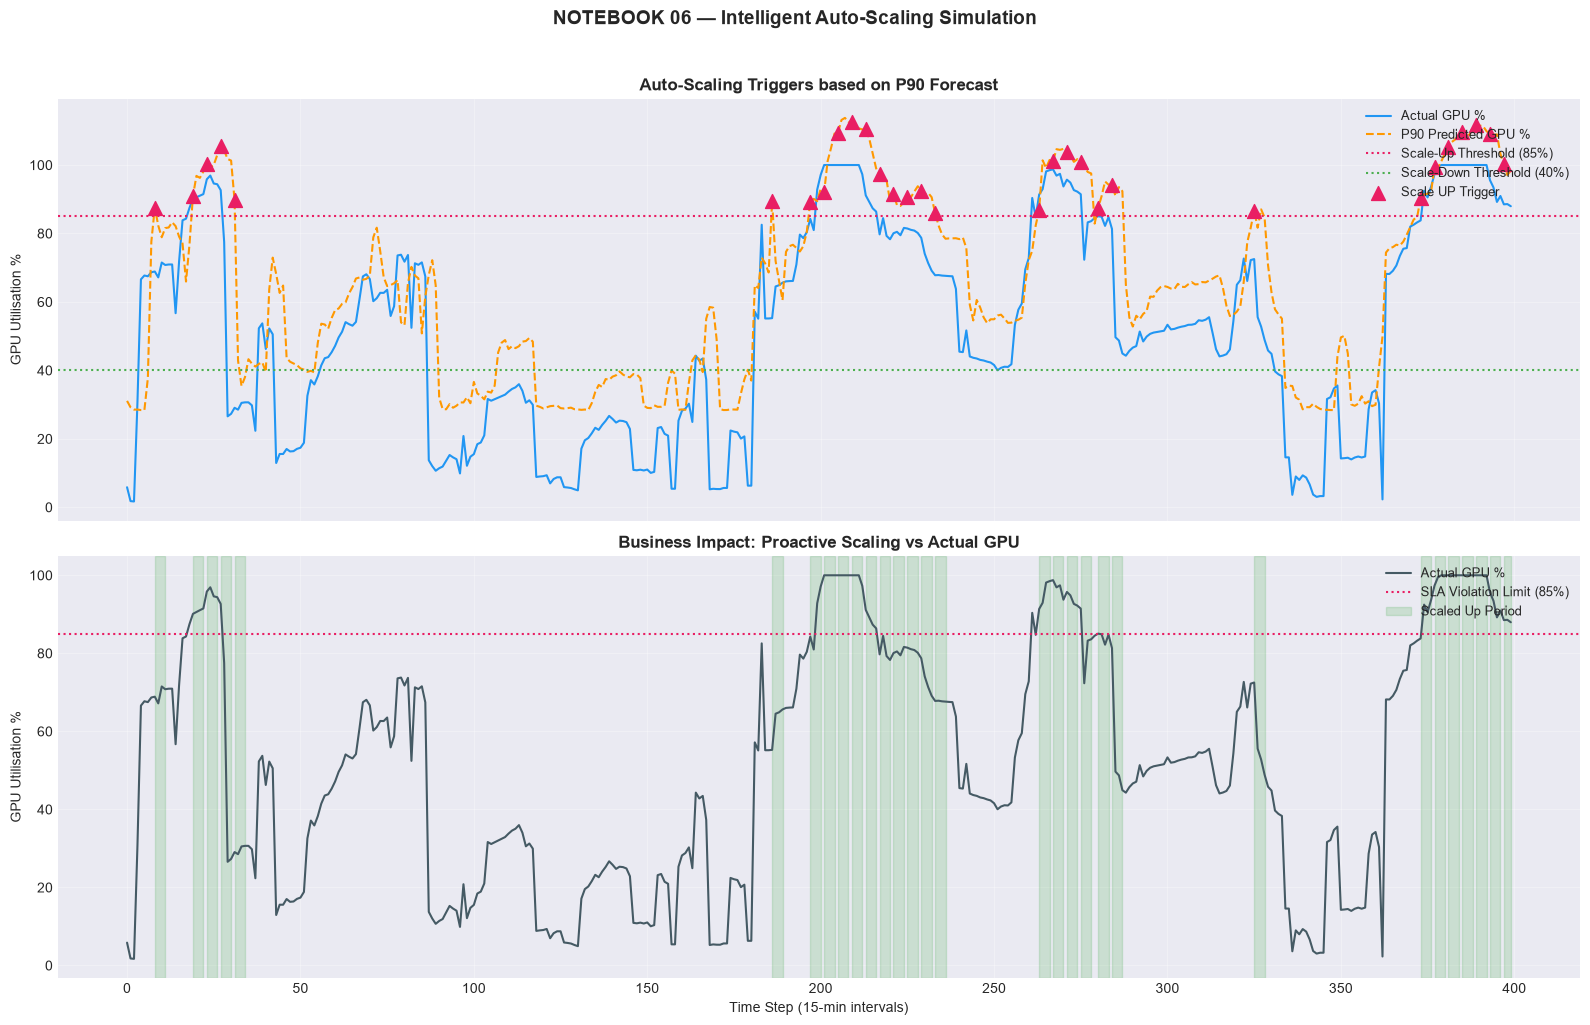

💾 Saved: autoscaling_simulation.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

n_show = min(400, len(sim_df))
plot_df = sim_df.iloc[:n_show].reset_index(drop=True)

axes[0].plot(plot_df.index, plot_df['actual_gpu'], label="Actual GPU %", color="#2196F3", lw=1.5)
axes[0].plot(plot_df.index, plot_df['predicted_p90_gpu'], label="P90 Predicted GPU %", color="#FF9800", lw=1.5, linestyle="--")
axes[0].axhline(SCALE_UP_THRESHOLD, color="#E91E63", linestyle=":", label="Scale-Up Threshold (85%)")
axes[0].axhline(SCALE_DOWN_THRESHOLD, color="#4CAF50", linestyle=":", label="Scale-Down Threshold (40%)")

scale_ups = plot_df[plot_df['decision'] == 'SCALE UP ⬆️']
axes[0].scatter(scale_ups.index, scale_ups['predicted_p90_gpu'], color="#E91E63", s=100, marker="^", label="Scale UP Trigger", zorder=5)

axes[0].set_title("Auto-Scaling Triggers based on P90 Forecast", fontsize=12, fontweight="bold")
axes[0].set_ylabel("GPU Utilisation %")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_df.index, plot_df['actual_gpu'], label="Actual GPU %", color="#455A64", lw=1.5)
axes[1].axhline(85.0, color="#E91E63", linestyle=":", label="SLA Violation Limit (85%)")

for idx, row in scale_ups.iterrows():
    axes[1].axvspan(idx, min(idx + COOLDOWN_PERIOD, n_show-1), color="#4CAF50", alpha=0.2, label="Scaled Up Period" if idx == scale_ups.index[0] else "")

axes[1].set_title("Business Impact: Proactive Scaling vs Actual GPU", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Time Step (15-min intervals)")
axes[1].set_ylabel("GPU Utilisation %")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("NOTEBOOK 06 — Intelligent Auto-Scaling Simulation", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/autoscaling_simulation.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Saved: autoscaling_simulation.png")